In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv(r"C:\Users\Pratyasha\AppData\Local\Packages\5319275A.WhatsAppDesktop_cv1g1gvanyjgm\LocalState\sessions\D86609983217273441CD23F11548986D8DF120DD\transfers\2026-09\industrial_regression_8_features.csv")
df.info

<bound method DataFrame.info of       Feature_1  Feature_2  Feature_3  Feature_4  Feature_5  Feature_6  \
0     -0.332609  -1.869104   1.203200  -0.744479   0.539057   1.097824   
1      0.024831  -0.468055   0.720370   0.589415  -1.269409  -0.076169   
2      1.002419  -1.288968  -0.015024   2.010774   1.062531  -1.891806   
3      0.798593   0.932500  -0.134170   1.124872  -0.233013   0.557943   
4     -0.761492   0.269842   0.998905   0.772251  -0.777531  -1.902083   
...         ...        ...        ...        ...        ...        ...   
1495   0.436713  -1.101480   0.181366   0.298132  -1.002655  -0.400021   
1496  -0.742554   1.049397  -2.288315   1.072470  -0.045386  -0.405228   
1497  -0.217824  -0.450005   1.100324   1.264812  -1.188656  -0.347147   
1498  -0.055433  -1.895940  -1.564364  -0.076943   0.040866  -0.217654   
1499  -0.387140   1.650700  -1.526525   2.029072   0.554580   0.274460   

      Feature_7  Feature_8      Target  
0     -0.893188  -0.539991 -192.634663

In [10]:
df.isnull().sum()

Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Feature_5    0
Feature_6    0
Feature_7    0
Feature_8    0
Target       0
dtype: int64

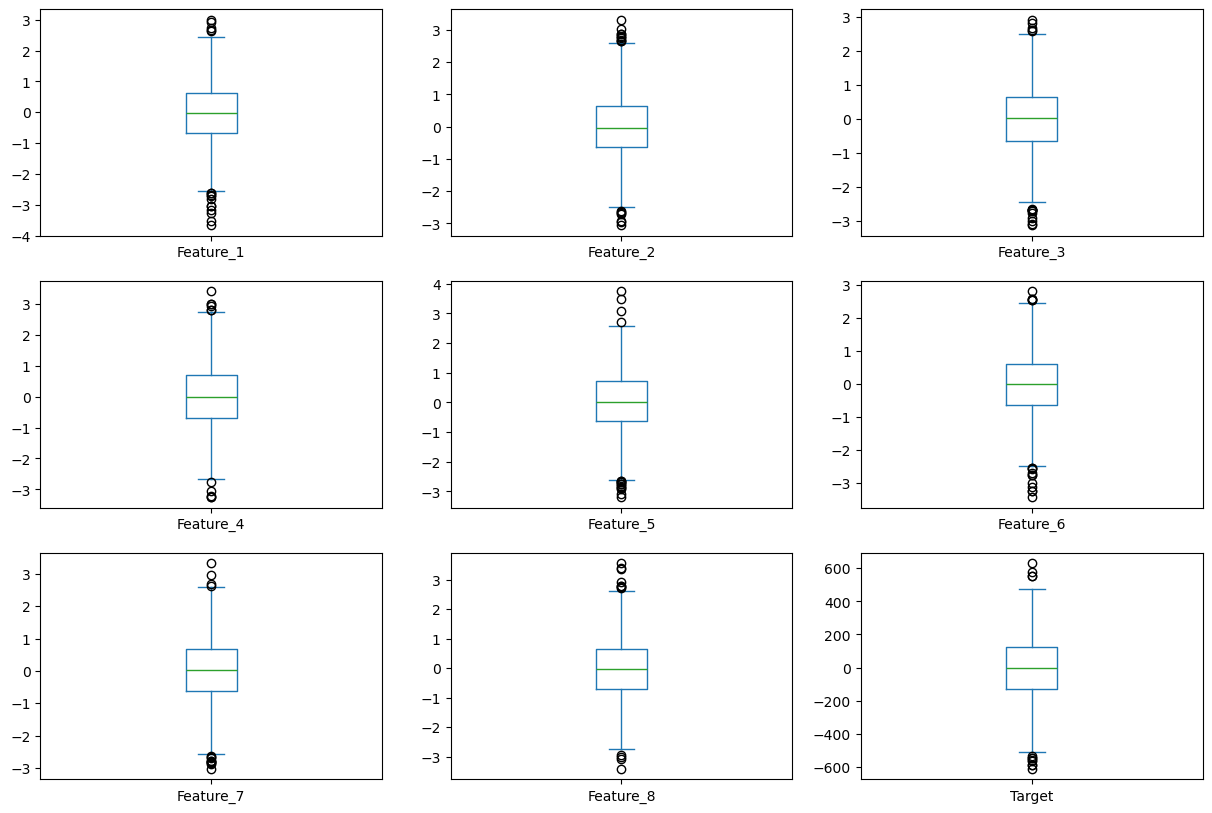

In [15]:
df.plot(kind='box', subplots=True, layout=(3, 3), figsize=(15, 10))
plt.show()

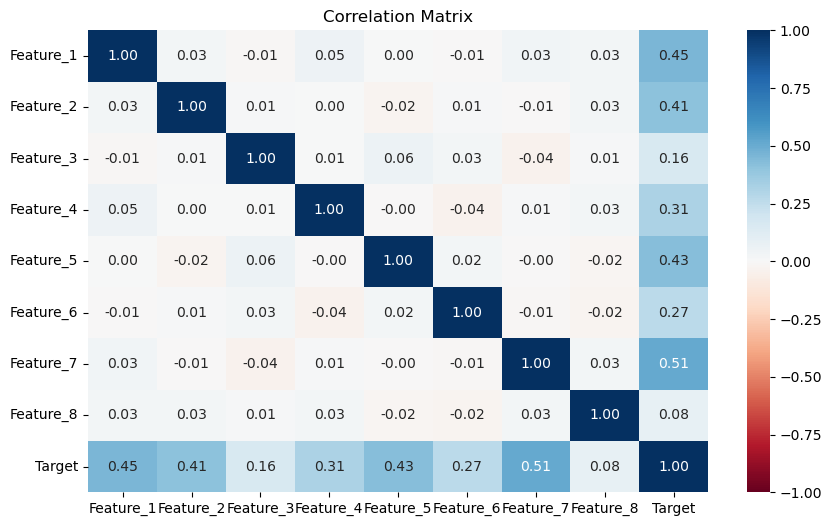

In [8]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='RdBu', fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()

In [13]:
df = df.drop_duplicates()

In [14]:
X = df.drop('Target', axis=1)
y = df['Target']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train)

alphas = [0.01, 0.1, 1, 10, 50, 100]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train_scaled, y_train)

print("Models trained successfully.")
lasso_cv = LassoCV(cv=5, random_state=42) 
lasso_cv.fit(X_train_scaled, y_train)

print(f"Best Ridge Alpha: {ridge_cv.alpha_}")
print(f"Best Lasso Alpha: {lasso_cv.alpha_}")

Models trained successfully.
Best Ridge Alpha: 0.1
Best Lasso Alpha: 0.09889188298283766


In [28]:
def get_metrics(model, X, y_true, name):
    y_pred = model.predict(X)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    n = X.shape[0]     
    p = X.shape[1]      
    
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
    
    return [name, rmse, r2, adj_r2]

results = []
results.append(get_metrics(lin_reg, X_test_scaled, y_test, 'Linear Regression'))
results.append(get_metrics(ridge_cv, X_test_scaled, y_test, 'Ridge Regression (CV)'))
results.append(get_metrics(lasso_cv, X_test_scaled, y_test, 'Lasso Regression (CV)'))

results_df = pd.DataFrame(results, columns=['Model', 'RMSE', 'R2 Score', 'Adj R2 Score'])
print(results_df)

                   Model       RMSE  R2 Score  Adj R2 Score
0      Linear Regression  20.460112  0.988193      0.987869
1  Ridge Regression (CV)  20.458303  0.988195      0.987871
2  Lasso Regression (CV)  20.439867  0.988216      0.987893
